In [15]:
import os
import sys
import numpy as np
import pandas as pd
import plotly.express as px

from sklearn.preprocessing import StandardScaler, normalize 
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA

import umap
import hdbscan

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Global paramters
INPUT_DIR = "../../data/embedded"
LABELS_PATH = "../../data/preprocessed/cleaned_labels.csv"
OUTPUT_DIR = "../../data/results"
RANDOM_STATE = 42

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [3]:
# LOAD DATA
def load_data_recursive(input_dir):
    embeddings_list = []
    filenames = []

    print(f"Scanning '{input_dir}' for embeddings...")

    files_found = 0
    for root, dirs, files in os.walk(input_dir):
        for file in files:
            if file.endswith(".npy"):
                file_path = os.path.join(root, file)

                try:
                    data = np.load(file_path)

                    if data.ndim == 0:
                        continue
                    elif data.ndim == 2:
                        data = data.squeeze()

                    if data.shape != (1024,):
                        continue

                    embeddings_list.append(data)
                    filenames.append(file.replace(".npy", ""))
                    files_found += 1

                except Exception as e:
                    print(f"Error loading {file}: {e}")

    if files_found == 0:
        return None, None

    print(f"Found {files_found} valid files.")

    X = np.vstack(embeddings_list)

    if not os.path.exists(INPUT_DIR):
        print(f"Error: Directory '{INPUT_DIR}' not found.")
        sys.exit(0)
    
    if X is None:
        print("No valid embeddings found. Check your directory.")
        sys.exit(0)
    
    print(f"Final Matrix Shape: {X.shape} (Samples: {X.shape[0]}, Features: {X.shape[1]})")
    return X, filenames

In [4]:
print("1. Loading data...")
X, filenames = load_data_recursive(INPUT_DIR)

1. Loading data...
Scanning '../../data/embedded' for embeddings...
Found 16272 valid files.
Final Matrix Shape: (16272, 1024) (Samples: 16272, Features: 1024)


In [5]:
print("1.5 Loading labels to balance the dataset...")
df_data = pd.DataFrame(X)
df_data["ecg_id"] = np.array(filenames).astype(int)

true_labels_df = pd.read_csv(LABELS_PATH)

df_merged = df_data.merge(true_labels_df[["ecg_id", "label"]], on="ecg_id", how="inner")
df_merged.dropna(subset="label")

print("\nOriginal class distribution:")
print(df_merged["label"].value_counts())

min_class_size = df_merged["label"].value_counts().min()

df_balanced = df_merged.groupby("label").sample(n=min_class_size, random_state=RANDOM_STATE)

print("\nBalanced class distribution:")
print(df_balanced["label"].value_counts())

X_balanced = df_balanced.drop(columns=["ecg_id", "label"]).values

filenames_balanced = df_balanced["ecg_id"].astype(str).str.zfill(5).tolist()

print(f"\nProceeding with {len(X_balanced)} perfectly balanced samples...")

1.5 Loading labels to balance the dataset...

Original class distribution:
label
NORM    9083
MI      2538
STTC    2406
CD      1709
HYP      536
Name: count, dtype: int64

Balanced class distribution:
label
CD      536
HYP     536
MI      536
NORM    536
STTC    536
Name: count, dtype: int64

Proceeding with 2680 perfectly balanced samples...


In [6]:
X_full = df_merged.drop(columns=["ecg_id", "label"]).values
true_labels_full = df_merged["label"].values

true_labels_balanced = df_balanced["label"].values

print("2. Scaling features...")
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X_full)

2. Scaling features...


In [7]:
print("2. Scaling features...")
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X_full)

scaler_balanced = StandardScaler()
X_scaled_balanced = scaler_balanced.fit_transform(X_balanced)

print("3. Normalizing data...") # For cosine distance
X_norm_full = normalize(X_scaled_full, norm="l2")
X_norm_balanced = normalize(X_scaled_balanced, norm="l2")

2. Scaling features...
3. Normalizing data...


In [8]:
# Master search config

## HDBSCAN Strategy
HDBSCAN_SPACE = {
    "n_neighbors_min": 5,
    "n_neighbors_max": 50,
    "min_dist_min": 0.0,
    "min_dist_max": 0.5,
    "min_cluster_size_min": 10,
    "min_cluster_size_max": 50,
    "min_samples_min": 3,
    "max_samples_cap": 25,
    "umap_components": 10
}

HDBSCAN_CONSTRAINTS = {
    "max_noise": 0.30,
    "min_clusters": 3,
    "max_clusters": 10
}

## GMM Strategy
GMM_SPACE = {
    "pca_comp_min": 5,
    "pca_comp_max": 50,
    "n_components_gmm": 5,
    "cov_types": ["full", "tied", "diag", "spherical"],
    "init_types": ["kmeans", "k-means++", "random"],
    "n_init": 5
}

N_TRIALS = 100

In [9]:
import optuna

In [10]:
def create_hdbscan_study(X_data, true_labels, space, constraints):

    def objective(trial):
        n_neighbors = trial.suggest_int("n_neighbors", space["n_neighbors_min"], space["n_neighbors_max"])
        min_dist = trial.suggest_float("min_dist", space["min_dist_min"], space["min_dist_max"])
        min_cluster_size = trial.suggest_int("min_cluster_size", space["min_cluster_size_min"], space["min_cluster_size_max"])
        
        max_samples_allowed = min(space["max_samples_cap"], min_cluster_size)
        min_samples = trial.suggest_int("min_samples", space["min_samples_min"], max_samples_allowed)

        reducer = umap.UMAP(n_components=space["umap_components"], n_neighbors=n_neighbors, min_dist=min_dist, metric='cosine', random_state=RANDOM_STATE)
        X_umap = reducer.fit_transform(X_data)

        clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples, metric="euclidean")
        labels = clusterer.fit_predict(X_umap)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_ratio = list(labels).count(-1) / len(labels)

        if noise_ratio > constraints["max_noise"] or n_clusters > constraints["max_clusters"] or n_clusters < constraints["min_clusters"]:
            return -1.0

        valid_idx = labels != -1
        if len(set(labels[valid_idx])) > 1:
            return adjusted_rand_score(true_labels[valid_idx], labels[valid_idx])
        return -1.0

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=N_TRIALS)
    return study

In [11]:
def create_gmm_study(X_data, true_labels, space):
    
    def objective(trial):
        n_components_pca = trial.suggest_int("n_components_pca", space["pca_comp_min"], space["pca_comp_max"])
        
        reducer = PCA(n_components=n_components_pca, random_state=RANDOM_STATE)
        X_reduced = reducer.fit_transform(X_data)

        covariance_type = trial.suggest_categorical("covariance_type", space["cov_types"])
        init_params = trial.suggest_categorical("init_params", space["init_types"])

        gmm = GaussianMixture(
            n_components=space["n_components_gmm"], 
            covariance_type=covariance_type, 
            init_params=init_params, 
            n_init=space["n_init"], 
            random_state=RANDOM_STATE
        )
        labels = gmm.fit_predict(X_reduced)

        return adjusted_rand_score(true_labels, labels)

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=N_TRIALS)
    return study

In [12]:
def evaluate_final_model(true_labels, pred_labels, name):
    print("="*30)
    print(f"FINAL MODEL METRICS ({name})")
    print("="*30)

    n_clusters = len(set(pred_labels)) - (1 if -1 in pred_labels else 0)
    noise_ratio = list(pred_labels).count(-1) / len(pred_labels)
    
    print(f"Clusters Found: {n_clusters}")
    print(f"Noise Ratio:    {noise_ratio*100:.1f}%")

    valid_idx = pred_labels != -1
    
    if n_clusters > 0 and sum(valid_idx) > 0:
        ari = adjusted_rand_score(true_labels[valid_idx], pred_labels[valid_idx])
        nmi = normalized_mutual_info_score(true_labels[valid_idx], pred_labels[valid_idx])
        print(f"Adjusted Rand Index (ARI): {ari:.4f}")
        print(f"Normalized Mutual Info (NMI):  {nmi:.4f}")

        mapped_preds = np.zeros_like(pred_labels, dtype=object)
        true_labels_series = pd.Series(true_labels)

        for cluster_id in np.unique(pred_labels):
            if cluster_id == -1: continue

            idx = np.where(pred_labels == cluster_id)[0]
            majority_disease = true_labels_series.iloc[idx].mode()[0]

            mapped_preds[idx] = majority_disease

        acc = accuracy_score(true_labels_series.iloc[valid_idx], mapped_preds[valid_idx])
        print(f"Cluster Purity Accuracy:   {acc*100:.1f}%")
        print(f"(Evaluated on {sum(valid_idx)} core points)")
    else:
        print("Model failed to find valid clusters. Everything is noise.")
        print("========================================\n")

In [13]:
def plot_final_generic_model(X_for_plot, true_labels, final_labels, name):
    print("--- Reducing to 2D for the final plot ---")
    plot_reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, metric="cosine", random_state=RANDOM_STATE)
    X_2d_plot = plot_reducer.fit_transform(X_for_plot)
    
    df_plot_final = pd.DataFrame(X_2d_plot, columns=['Dimension 1', 'Dimension 2'])
    df_plot_final['Cluster'] = final_labels.astype(str)
    df_plot_final['label'] = true_labels
    
    fig = px.scatter(
        df_plot_final, 
        x="Dimension 1",
        y="Dimension 2", 
        color="label", 
        symbol="Cluster",
        hover_data={"label": True, "Cluster": True, "Dimension 1": False, "Dimension 2": False},
        title=f"Final Optimized MOMENT Embeddings ({name})",
        color_discrete_sequence=px.colors.qualitative.Plotly
    )
    
    fig.update_traces(marker=dict(size=8, opacity=0.7))
    fig.update_layout(template="plotly_white")
    fig.show()

In [16]:
print("--- RUNNING UNBALANCED DATASET ---")

print("\nOptimizing HDBSCAN (Full)...")
study_hdbscan_full = create_hdbscan_study(X_norm_full, true_labels_full, HDBSCAN_SPACE, HDBSCAN_CONSTRAINTS)

print("\nOptimizing GMM (Full)...")
study_gmm_full = create_gmm_study(X_norm_full, true_labels_full, GMM_SPACE)

[I 2026-04-12 10:34:55,281] A new study created in memory with name: no-name-113a6a18-14f1-4cb4-87ab-3545ca0a15d3


--- RUNNING UNBALANCED DATASET ---

Optimizing HDBSCAN (Full)...


[I 2026-04-12 10:35:22,700] Trial 0 finished with value: 0.09068582382036715 and parameters: {'n_neighbors': 47, 'min_dist': 0.10051722202458385, 'min_cluster_size': 28, 'min_samples': 21}. Best is trial 0 with value: 0.09068582382036715.
[I 2026-04-12 10:35:51,027] Trial 1 finished with value: -1.0 and parameters: {'n_neighbors': 49, 'min_dist': 0.17786318891120179, 'min_cluster_size': 27, 'min_samples': 6}. Best is trial 0 with value: 0.09068582382036715.
[I 2026-04-12 10:36:20,023] Trial 2 finished with value: -1.0 and parameters: {'n_neighbors': 47, 'min_dist': 0.39330769301117724, 'min_cluster_size': 35, 'min_samples': 25}. Best is trial 0 with value: 0.09068582382036715.
[I 2026-04-12 10:36:37,152] Trial 3 finished with value: 0.00525093319263668 and parameters: {'n_neighbors': 18, 'min_dist': 0.48981741056537476, 'min_cluster_size': 16, 'min_samples': 11}. Best is trial 0 with value: 0.09068582382036715.
[I 2026-04-12 10:36:52,276] Trial 4 finished with value: -1.0 and parameter


Optimizing GMM (Full)...


[I 2026-04-12 11:16:43,009] Trial 0 finished with value: 0.008798120262003214 and parameters: {'n_components_pca': 13, 'covariance_type': 'tied', 'init_params': 'k-means++'}. Best is trial 0 with value: 0.008798120262003214.
[I 2026-04-12 11:16:53,059] Trial 1 finished with value: 0.04198703082043765 and parameters: {'n_components_pca': 42, 'covariance_type': 'tied', 'init_params': 'kmeans'}. Best is trial 1 with value: 0.04198703082043765.
[I 2026-04-12 11:16:55,851] Trial 2 finished with value: 0.011539741991751633 and parameters: {'n_components_pca': 37, 'covariance_type': 'diag', 'init_params': 'k-means++'}. Best is trial 1 with value: 0.04198703082043765.
[I 2026-04-12 11:16:56,502] Trial 3 finished with value: 0.06125536652198646 and parameters: {'n_components_pca': 18, 'covariance_type': 'tied', 'init_params': 'k-means++'}. Best is trial 3 with value: 0.06125536652198646.
[I 2026-04-12 11:16:58,036] Trial 4 finished with value: 0.06600645727468622 and parameters: {'n_components_

Building Full HDBSCAN with: {'n_neighbors': 38, 'min_dist': 0.15108826994338137, 'min_cluster_size': 31, 'min_samples': 21}
FINAL MODEL METRICS (HDBSCAN (Unbalanced))
Clusters Found: 7
Noise Ratio:    28.9%
Adjusted Rand Index (ARI): 0.1199
Normalized Mutual Info (NMI):  0.1323
Cluster Purity Accuracy:   60.9%
(Evaluated on 11576 core points)
--- Reducing to 2D for the final plot ---


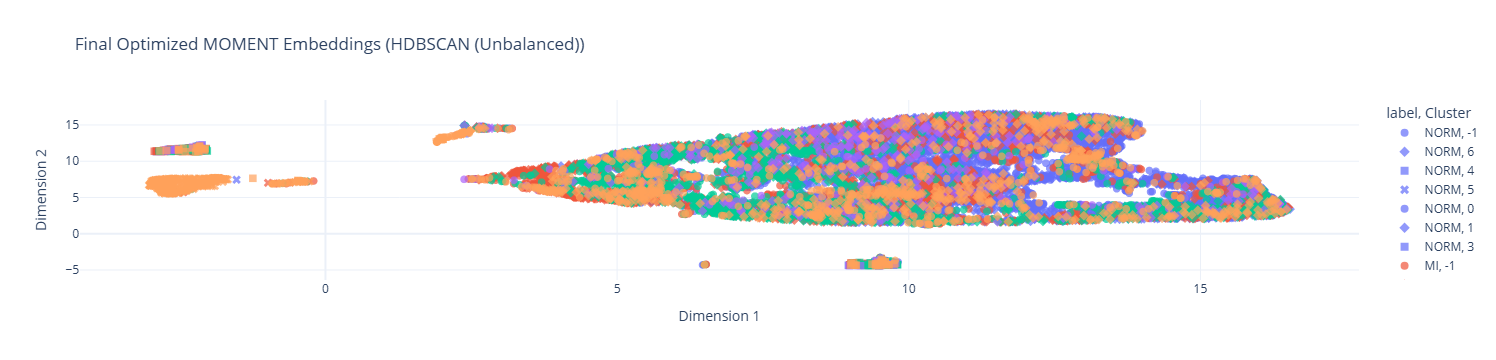

Building Full GMM with: {'n_components_pca': 17, 'covariance_type': 'full', 'init_params': 'random'}
FINAL MODEL METRICS (GMM (Unbalanced))
Clusters Found: 5
Noise Ratio:    0.0%
Adjusted Rand Index (ARI): 0.2391
Normalized Mutual Info (NMI):  0.1525
Cluster Purity Accuracy:   61.1%
(Evaluated on 16272 core points)
--- Reducing to 2D for the final plot ---


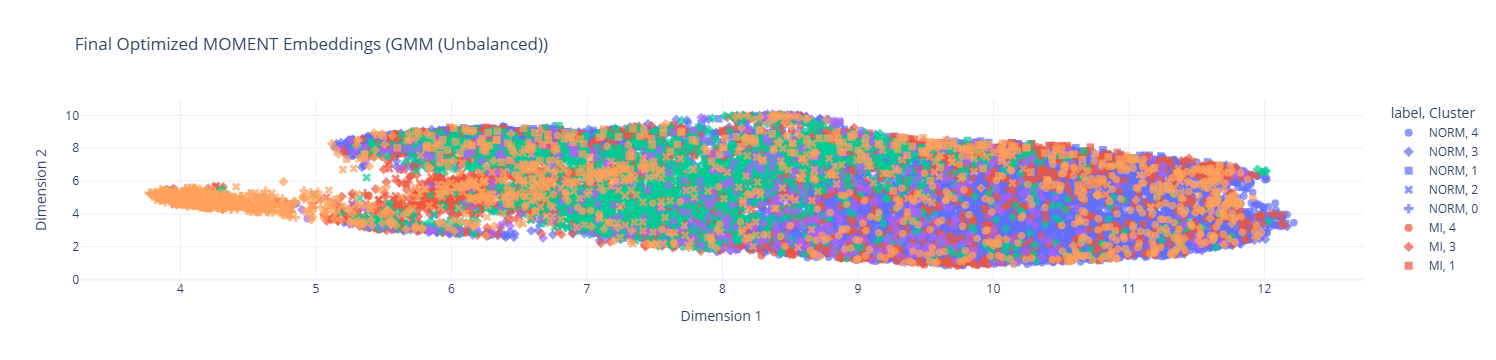

In [18]:
from sklearn.metrics import accuracy_score

# --- 1. FULL HDBSCAN ---
best_h_full = study_hdbscan_full.best_params
print(f"Building Full HDBSCAN with: {best_h_full}")

hdbscan_reducer_full = umap.UMAP(
    n_components=HDBSCAN_SPACE["umap_components"], 
    n_neighbors=best_h_full["n_neighbors"], 
    min_dist=best_h_full["min_dist"], 
    metric="cosine", 
    random_state=RANDOM_STATE
)
X_umap_full = hdbscan_reducer_full.fit_transform(X_norm_full)

hdbscan_model_full = hdbscan.HDBSCAN(
    min_cluster_size=best_h_full["min_cluster_size"], 
    min_samples=best_h_full["min_samples"], 
    metric="euclidean"
)
labels_hdbscan_full = hdbscan_model_full.fit_predict(X_umap_full)

evaluate_final_model(
    true_labels_full, 
    labels_hdbscan_full, 
    "HDBSCAN (Unbalanced)"
)
plot_final_generic_model(
    X_umap_full, 
    true_labels_full, 
    labels_hdbscan_full, 
    "HDBSCAN (Unbalanced)"
)

# --- 2. FULL GMM ---
best_gmm_full = study_gmm_full.best_params
print(f"Building Full GMM with: {best_gmm_full}")

pca_reducer_full = PCA(
    n_components=best_gmm_full["n_components_pca"], 
    random_state=RANDOM_STATE
)
X_pca_full = pca_reducer_full.fit_transform(X_norm_full)

gmm_model_full = GaussianMixture(
    n_components=GMM_SPACE["n_components_gmm"], 
    covariance_type=best_gmm_full["covariance_type"], 
    init_params=best_gmm_full["init_params"], 
    n_init=GMM_SPACE["n_init"], 
    random_state=RANDOM_STATE
)
labels_gmm_full = gmm_model_full.fit_predict(X_pca_full)

evaluate_final_model(
    true_labels_full, 
    labels_gmm_full, 
    "GMM (Unbalanced)"
)
plot_final_generic_model(
    X_pca_full, 
    true_labels_full, 
    labels_gmm_full, 
    "GMM (Unbalanced)"
)

In [19]:
print("--- RUNNING BALANCED DATASET ---")

print("\nOptimizing HDBSCAN (Balanced)...")
study_hdbscan_balanced = create_hdbscan_study(X_norm_balanced, true_labels_balanced, HDBSCAN_SPACE, HDBSCAN_CONSTRAINTS)

print("\nOptimizing GMM (Balanced)...")
study_gmm_balanced = create_gmm_study(X_norm_balanced, true_labels_balanced, GMM_SPACE)

--- RUNNING BALANCED DATASET ---

Optimizing HDBSCAN (Balanced)...


[I 2026-04-12 12:20:02,508] A new study created in memory with name: no-name-74e0c77c-8b50-44b2-8546-6677e36f5940
[I 2026-04-12 12:20:23,088] Trial 0 finished with value: -1.0 and parameters: {'n_neighbors': 12, 'min_dist': 0.06868810146603199, 'min_cluster_size': 16, 'min_samples': 11}. Best is trial 0 with value: -1.0.
[I 2026-04-12 12:20:38,786] Trial 1 finished with value: 0.02515959025347503 and parameters: {'n_neighbors': 16, 'min_dist': 0.4899357858407625, 'min_cluster_size': 35, 'min_samples': 15}. Best is trial 1 with value: 0.02515959025347503.
[I 2026-04-12 12:20:53,161] Trial 2 finished with value: 0.02218888458416288 and parameters: {'n_neighbors': 7, 'min_dist': 0.129672681401437, 'min_cluster_size': 46, 'min_samples': 24}. Best is trial 1 with value: 0.02515959025347503.
[I 2026-04-12 12:21:09,842] Trial 3 finished with value: -1.0 and parameters: {'n_neighbors': 31, 'min_dist': 0.22557143017750952, 'min_cluster_size': 17, 'min_samples': 5}. Best is trial 1 with value: 0


Optimizing GMM (Balanced)...


[I 2026-04-12 12:48:04,638] A new study created in memory with name: no-name-8195171f-5115-401a-bd0d-b5193ae42881
[I 2026-04-12 12:48:04,831] Trial 0 finished with value: 0.040212404006478415 and parameters: {'n_components_pca': 6, 'covariance_type': 'diag', 'init_params': 'k-means++'}. Best is trial 0 with value: 0.040212404006478415.
[I 2026-04-12 12:48:05,070] Trial 1 finished with value: 0.043170983980153586 and parameters: {'n_components_pca': 14, 'covariance_type': 'spherical', 'init_params': 'k-means++'}. Best is trial 1 with value: 0.043170983980153586.
[I 2026-04-12 12:48:05,644] Trial 2 finished with value: 0.04476913963276093 and parameters: {'n_components_pca': 37, 'covariance_type': 'spherical', 'init_params': 'random'}. Best is trial 2 with value: 0.04476913963276093.
[I 2026-04-12 12:48:05,709] Trial 3 finished with value: 0.06467805151354272 and parameters: {'n_components_pca': 6, 'covariance_type': 'tied', 'init_params': 'k-means++'}. Best is trial 3 with value: 0.0646

Building Balanced HDBSCAN with: {'n_neighbors': 11, 'min_dist': 0.2917455274191454, 'min_cluster_size': 47, 'min_samples': 20}
FINAL MODEL METRICS (HDBSCAN (Balanced))
Clusters Found: 3
Noise Ratio:    29.3%
Adjusted Rand Index (ARI): 0.0280
Normalized Mutual Info (NMI):  0.1312
Cluster Purity Accuracy:   30.7%
(Evaluated on 1895 core points)
--- Reducing to 2D for the final plot ---


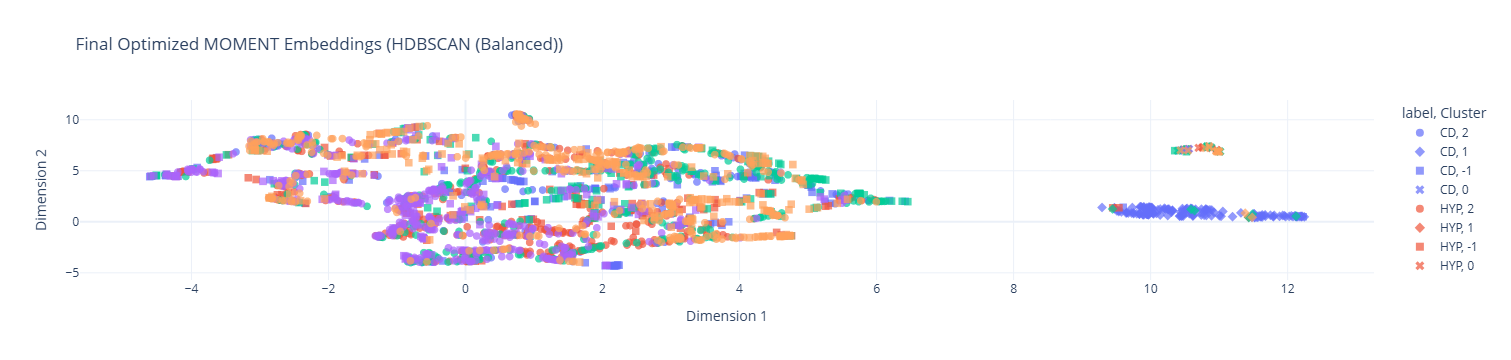

Building Balanced GMM with: {'n_components_pca': 36, 'covariance_type': 'full', 'init_params': 'random'}
FINAL MODEL METRICS (GMM (Balanced))
Clusters Found: 5
Noise Ratio:    0.0%
Adjusted Rand Index (ARI): 0.0835
Normalized Mutual Info (NMI):  0.1238
Cluster Purity Accuracy:   38.1%
(Evaluated on 2680 core points)
--- Reducing to 2D for the final plot ---


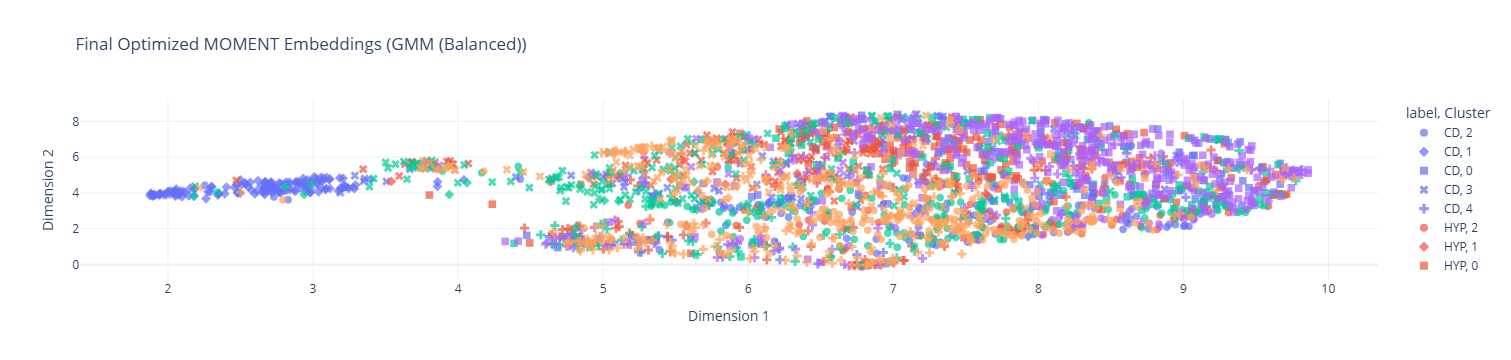

In [21]:
# --- 1. BALANCED HDBSCAN ---
best_h_bal = study_hdbscan_balanced.best_params
print(f"Building Balanced HDBSCAN with: {best_h_bal}")

hdbscan_reducer_bal = umap.UMAP(
    n_components=HDBSCAN_SPACE["umap_components"], 
    n_neighbors=best_h_bal["n_neighbors"], 
    min_dist=best_h_bal["min_dist"], 
    metric="cosine", 
    random_state=RANDOM_STATE
)
X_umap_bal = hdbscan_reducer_bal.fit_transform(X_norm_balanced)

hdbscan_model_bal = hdbscan.HDBSCAN(
    min_cluster_size=best_h_bal["min_cluster_size"], 
    min_samples=best_h_bal["min_samples"], 
    metric="euclidean"
)
labels_hdbscan_bal = hdbscan_model_bal.fit_predict(X_umap_bal)

evaluate_final_model(
    true_labels_balanced, 
    labels_hdbscan_bal, 
    "HDBSCAN (Balanced)"
)
plot_final_generic_model(
    X_umap_bal,
    true_labels_balanced,
    labels_hdbscan_bal,
    "HDBSCAN (Balanced)"
)


# --- 2. BALANCED GMM ---
best_gmm_bal = study_gmm_balanced.best_params
print(f"Building Balanced GMM with: {best_gmm_bal}")

pca_reducer_bal = PCA(
    n_components=best_gmm_bal["n_components_pca"], 
    random_state=RANDOM_STATE
)
X_pca_bal = pca_reducer_bal.fit_transform(X_norm_balanced)

gmm_model_bal = GaussianMixture(
    n_components=GMM_SPACE["n_components_gmm"], 
    covariance_type=best_gmm_bal["covariance_type"], 
    init_params=best_gmm_bal["init_params"], 
    n_init=GMM_SPACE["n_init"], 
    random_state=RANDOM_STATE
)
labels_gmm_bal = gmm_model_bal.fit_predict(X_pca_bal)

evaluate_final_model(
    true_labels_balanced,
    labels_gmm_bal,
    "GMM (Balanced)"
)
plot_final_generic_model(
    X_pca_bal,
    true_labels_balanced,
    labels_gmm_bal,
    "GMM (Balanced)"
)

In [40]:
def hdbscan_objective(trial):
    n_neighbors = trial.suggest_int("n_neighbors", 5, 50)
    min_dist = trial.suggest_float("min_dist", 0.0, 0.5)
    min_cluster_size = trial.suggest_int("min_cluster_size", 5, 50)
    min_samples = trial.suggest_int("min_samples", 3, 25)

    reducer = umap.UMAP(n_components=N_COMPONENTS_UMAP_HDBSCAN, n_neighbors=n_neighbors, min_dist=min_dist)
    X_umap = reducer.fit_transform(X_norm)

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size = min_cluster_size,
        min_samples = min_samples,
        metric = "euclidean"
    )
    labels = clusterer.fit_predict(X_umap)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_ratio = list(labels).count(-1) / len(labels)

    if noise_ratio > MAX_NOISE_RATIO or n_clusters > MAX_N_CLUSTERS or n_clusters < MIN_N_CLUSTERS:
        return -1

    valid_idx = labels != -1

    if len(set(labels[valid_idx])) > 1:
        ari_score = adjusted_rand_score(true_labels[valid_idx], labels[valid_idx])
        return ari_score
    else:
        return -1.0

print("--- Starting Optuna Search ---")
study = optuna.create_study(direction="maximize")
study.optimize(hdbscan_objective, n_trials = N_TRIALS_UMAP_HDBSCAN_OPTUNA)

print("\n========================================")
print("OPTUNA BEST HONEST PARAMETERS")
print("========================================")
print(f"Best ARI Score: {study.best_value:.4f}")
print("Parameters:", study.best_params)
print("========================================")

--- Starting Optuna Search ---


[I 2026-04-11 16:02:28,212] A new study created in memory with name: no-name-855aa1a9-1037-4bce-b8e5-c8c7aecb6dfa
[I 2026-04-11 16:02:39,987] Trial 0 finished with value: 0.01696094108585021 and parameters: {'n_neighbors': 10, 'min_dist': 0.15028114652282437, 'min_cluster_size': 26, 'min_samples': 15}. Best is trial 0 with value: 0.01696094108585021.
[I 2026-04-11 16:02:55,218] Trial 1 finished with value: -1.0 and parameters: {'n_neighbors': 48, 'min_dist': 0.3161357980876692, 'min_cluster_size': 14, 'min_samples': 16}. Best is trial 0 with value: 0.01696094108585021.
[I 2026-04-11 16:03:08,781] Trial 2 finished with value: -1.0 and parameters: {'n_neighbors': 28, 'min_dist': 0.3989682543821908, 'min_cluster_size': 9, 'min_samples': 21}. Best is trial 0 with value: 0.01696094108585021.
[I 2026-04-11 16:03:21,623] Trial 3 finished with value: 0.0256131623958252 and parameters: {'n_neighbors': 20, 'min_dist': 0.3912614653051764, 'min_cluster_size': 32, 'min_samples': 25}. Best is trial 


OPTUNA BEST HONEST PARAMETERS
Best ARI Score: 0.0287
Parameters: {'n_neighbors': 34, 'min_dist': 0.38175295824988453, 'min_cluster_size': 28, 'min_samples': 25}


In [41]:
print("=" * 30)
print("BUILDING FINAL OPTIMIZED MODEL (HDBSCAN)")
print("=" * 30)

best_params = study.best_params
print(f"Using parameters: {best_params}")

print("\n1. Running UMAP with optimized parameters...")
final_reducer = umap.UMAP(
    n_components = N_COMPONENTS_UMAP_HDBSCAN,
    n_neighbors = best_params["n_neighbors"],
    min_dist = best_params["min_dist"],
    metric = "cosine",
    random_state = RANDOM_STATE
)
X_umap_final = final_reducer.fit_transform(X_norm)

print("2. Running HDBSCAN with optimized parameters...")
final_clusterer = hdbscan.HDBSCAN(
    min_cluster_size = best_params["min_cluster_size"],
    min_samples=best_params["min_samples"], 
    metric="euclidean"
)
final_labels = final_clusterer.fit_predict(X_umap_final)

BUILDING FINAL OPTIMIZED MODELL
Using parameters: {'n_neighbors': 34, 'min_dist': 0.38175295824988453, 'min_cluster_size': 28, 'min_samples': 25}

1. Running UMAP with optimized parameters...
2. Running HDBSCAN with optimized parameters...


In [53]:
evaluate_final_model(true_labels, final_labels, "HDBSCAN + UMAP")

FINAL MODEL METRICS (HDBSCAN + UMAP)
Clusters Found: 3
Noise Ratio:    30.5%
Adjusted Rand Index (ARI): 0.0291
Normalized Mutual Info (NMI):  0.1336
Cluster Purity Accuracy:   30.2%
(Evaluated on 1862 core points)


--- Reducing to 2D for the final plot ---


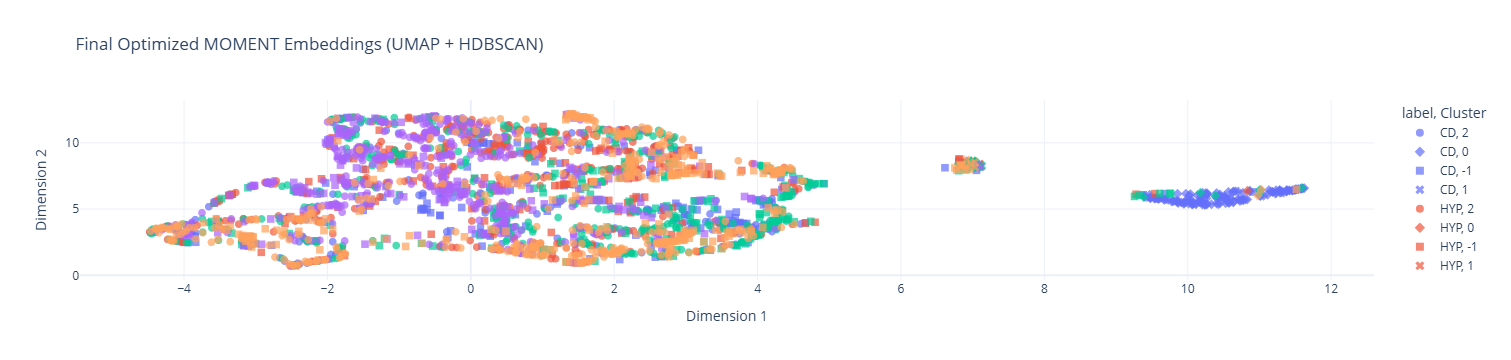

In [55]:
plot_final_generic_model(
    X_for_plot = X_umap_final, 
    true_labels = true_labels, 
    final_labels = final_labels, 
    name = "UMAP + HDBSCAN"
)

In [36]:
print("--- CLUSTERING WITH GAUSSIAN MIXTURE MODELS (GMM) ---")
reducer_gmm = PCA(n_components = 10, random_state = RANDOM_STATE)
X_gmm = reducer_gmm.fit_transform(X_norm)

gmm = GaussianMixture(n_components = 5, covariance_type = "full", random_state = RANDOM_STATE, n_init = 5)
gmm_labels = gmm.fit_predict(X_gmm)

true_labels = df_balanced['label'].values

ari_gmm = adjusted_rand_score(true_labels, gmm_labels)
nmi_gmm = normalized_mutual_info_score(true_labels, gmm_labels)

print("\n========================================")
print("GMM METRICS (Evaluating 100% of data)")
print("========================================")
print(f"Adjusted Rand Index (ARI): {ari_gmm:.4f}")
print(f"Normalized Mutual Info (NMI):  {nmi_gmm:.4f}")
print("========================================\n")

--- CLUSTERING WITH GAUSSIAN MIXTURE MODELS (GMM) ---

GMM METRICS (Evaluating 100% of data)
Adjusted Rand Index (ARI): 0.0755
Normalized Mutual Info (NMI):  0.1186



In [59]:
print("--- Starting Optuna Search for PCA + GMM ---")

def gmm_objective(trial):
    n_components_pca = trial.suggest_int("n_components_pca", 5, 50)
    
    reducer = PCA(n_components=n_components_pca, random_state=RANDOM_STATE)
    X_reduced = reducer.fit_transform(X_norm)

    covariance_type = trial.suggest_categorical("covariance_type", ["full", "tied", "diag", "spherical"])

    init_params = trial.suggest_categorical("init_params", ["kmeans", "k-means++", "random"])

    gmm = GaussianMixture(
        n_components = 5,
        covariance_type = covariance_type,
        init_params = init_params,
        n_init = 5,
        random_state = RANDOM_STATE
    )

    labels = gmm.fit_predict(X_reduced)

    ari_score = adjusted_rand_score(true_labels, labels)
    
    return ari_score

study_gmm = optuna.create_study(direction="maximize")
study_gmm.optimize(gmm_objective, n_trials=80)

print("\n========================================")
print("OPTUNA BEST GMM PARAMETERS")
print("========================================")
print(f"Best ARI Score: {study_gmm.best_value:.4f}")
print("Parameters:", study_gmm.best_params)
print("========================================")

--- Starting Optuna Search for PCA + GMM ---


[I 2026-04-11 16:31:09,793] A new study created in memory with name: no-name-1c1934d9-f57d-4ece-9dd2-2d073a22601c
[I 2026-04-11 16:31:10,084] Trial 0 finished with value: 0.022754523041863577 and parameters: {'n_components_pca': 29, 'covariance_type': 'diag', 'init_params': 'random'}. Best is trial 0 with value: 0.022754523041863577.
[I 2026-04-11 16:31:10,188] Trial 1 finished with value: 0.03517902622847355 and parameters: {'n_components_pca': 16, 'covariance_type': 'tied', 'init_params': 'k-means++'}. Best is trial 1 with value: 0.03517902622847355.
[I 2026-04-11 16:31:10,592] Trial 2 finished with value: 0.04365596226557646 and parameters: {'n_components_pca': 23, 'covariance_type': 'spherical', 'init_params': 'k-means++'}. Best is trial 2 with value: 0.04365596226557646.
[I 2026-04-11 16:31:10,818] Trial 3 finished with value: 0.03979647753573613 and parameters: {'n_components_pca': 8, 'covariance_type': 'spherical', 'init_params': 'k-means++'}. Best is trial 2 with value: 0.04365


OPTUNA BEST GMM PARAMETERS
Best ARI Score: 0.0843
Parameters: {'n_components_pca': 35, 'covariance_type': 'full', 'init_params': 'random'}


In [60]:
print("=" * 30)
print("BUILDING FINAL OPTIMIZED MODELL (GMM)")
print("=" * 30)

best_gmm_params = study_gmm.best_params
print(f"Using parameters: {best_gmm_params}")

print("\n1. Running PCA with optimized parameters...")
final_pca_reducer = PCA(
    n_components=best_gmm_params["n_components_pca"], 
    random_state=RANDOM_STATE
)
X_pca_final = final_pca_reducer.fit_transform(X_norm)

print("2. Running GMM with optimized parameters...")
final_gmm = GaussianMixture(
    n_components=5,
    covariance_type=best_gmm_params["covariance_type"],
    init_params=best_gmm_params["init_params"],
    n_init=5,
    random_state=RANDOM_STATE
)
final_gmm_labels = final_gmm.fit_predict(X_pca_final)

BUILDING FINAL OPTIMIZED MODELL (GMM)
Using parameters: {'n_components_pca': 35, 'covariance_type': 'full', 'init_params': 'random'}

1. Running PCA with optimized parameters...
2. Running GMM with optimized parameters...


In [61]:
evaluate_final_model(true_labels, final_gmm_labels, name="PCA + GMM")

FINAL MODEL METRICS (PCA + GMM)
Clusters Found: 5
Noise Ratio:    0.0%
Adjusted Rand Index (ARI): 0.0843
Normalized Mutual Info (NMI):  0.1121
Cluster Purity Accuracy:   36.9%
(Evaluated on 2680 core points)


--- Reducing to 2D for the final plot ---


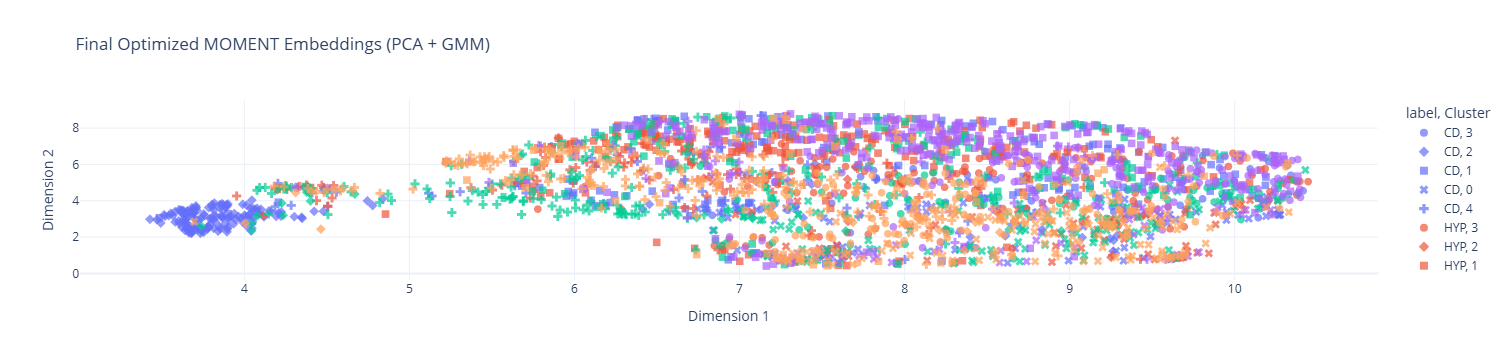

In [58]:
plot_final_generic_model(
    X_for_plot = X_pca_final, 
    true_labels = true_labels, 
    final_labels = final_gmm_labels, 
    name = "PCA + GMM"
)

In [6]:
print("4. Reducing with UMAP")
reducer = umap.UMAP(n_neighbors=30, n_components=10, min_dist=0.0, metric="cosine", random_state=42)
X_umap = reducer.fit_transform(X_norm)

2. Scaling features...
3. Normalizing data...
4. Reducing with UMAP


In [7]:
print("5. Clustering with HDBSCAN...")
clusterer = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=10, metric="euclidean")

preds = clusterer.fit_predict(X_umap)

n_clusters = len(set(preds)) - (1 if -1 in preds else 0)
n_noise = list(preds).count(-1)
print(f"HDBSCAN found {n_clusters} clusters and {n_noise}/{len(preds)} noise points.")

5. Clustering with HDBSCAN...
HDBSCAN found 8 clusters and 831/2680 noise points.


In [8]:
print("6. Reducing to 2D for plotting...")
reducer_2d = umap.UMAP(n_neighbors=30, n_components=2, min_dist=0.1, metric="cosine", random_state=42)
X_umap_2d = reducer_2d.fit_transform(X_umap)

6. Reducing to 2D for plotting...


In [10]:
def build_plot_dataframe(data, labels):
    df_plot = pd.DataFrame(data, columns=['UMAP 1', 'UMAP 2'])
    df_plot['Cluster'] = labels.astype(str)
    df_plot['Source'] = filenames_balanced
    df_plot['ecg_id'] = df_plot['Source'].astype(int)
    
    try:
        true_labels_df = pd.read_csv(LABELS_PATH)
        df_plot = df_plot.merge(true_labels_df[['ecg_id', 'label']], on='ecg_id', how='left')
        df_plot['label'] = df_plot['label'].fillna('Unknown')
    except Exception as e:
        df_plot['label'] = 'Unknown'

    return df_plot

df_plot = build_plot_dataframe(X_umap_2d, preds)

In [11]:
print("=" * 30)
print("UMAP + HDBSCAN METRICS")
print("=" * 30)

valid_idx = (df_plot["label"] != "Unknown") & (df_plot["Cluster"] != -1)
true_labels_valid = df_plot.loc[valid_idx, "label"]
pred_clusters_valid = df_plot.loc[valid_idx, "Cluster"]

if len(true_labels_valid) > 1:
    ari = adjusted_rand_score(true_labels_valid, pred_clusters_valid)
    nmi = normalized_mutual_info_score(true_labels_valid, pred_clusters_valid)
    print(f"Adjusted Rand Index (ARI): {ari:.4f}")
    print(f"Normalized Mutual Info (NMI):  {nmi:.4f}")
    print(f"Evaluated on {len(true_labels_valid)} core points")
else:
    print("Could not calculate ARI/NMI. Not enough valid true labels.")

UMAP + HDBSCAN METRICS
Adjusted Rand Index (ARI): 0.0344
Normalized Mutual Info (NMI):  0.0824
Evaluated on 2680 core points


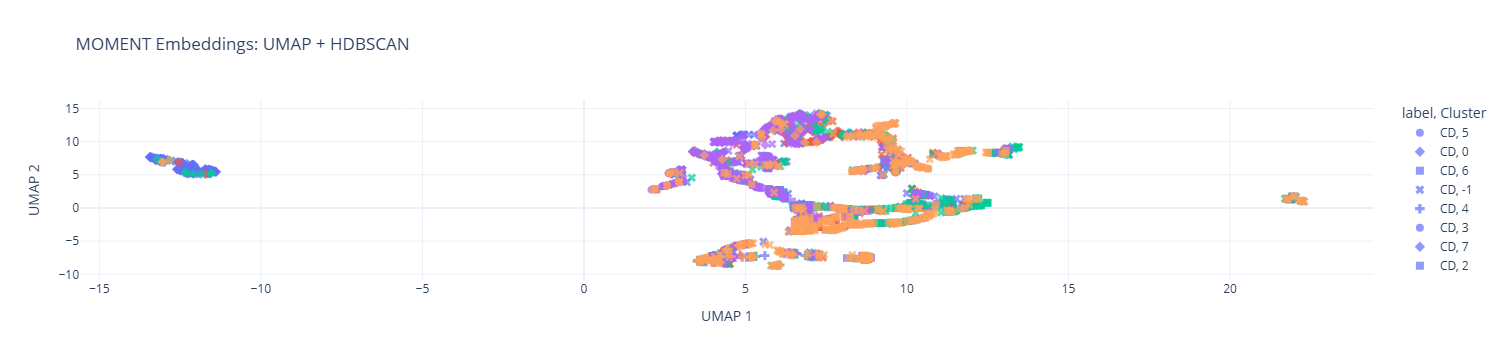

In [12]:
fig = px.scatter(
    df_plot,
    x = "UMAP 1",
    y = "UMAP 2",
    color = "label",
    symbol = "Cluster",
    hover_name = "Source",
    hover_data = {"label": True, "Cluster": True, "UMAP 1": False, "UMAP 2": False},
    title = "MOMENT Embeddings: UMAP + HDBSCAN",
    color_discrete_sequence = px.colors.qualitative.Plotly
)

fig.update_traces(marker=dict(size=8, opacity=0.7))
fig.update_layout(template="plotly_white")
fig.show()